## 1. Iris Dataset Dimensionality Reduction

Use the iris dataset in order to reduce its dimensionality down to three dimensions by using the PCA algorithm. Print the principal components and the explained variance ratio and plot the 3D dataset. Also visualize the data reduced to three dimensions using the t-SNE method.




In [6]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [2]:
iris_dataset = load_iris()

X = iris_dataset.data
y = iris_dataset.target

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state = 42)

In [3]:
# daca nu schimbam dimensionalitatea puteam da fit
pca = PCA(n_components = 3)
X3D = pca.fit_transform(X_train)

In [4]:
pca.components_

array([[ 0.36048094, -0.07851577,  0.85817545,  0.35696452],
       [ 0.66432471,  0.72083845, -0.17448097, -0.09284935],
       [-0.56833178,  0.61047969,  0.06681214,  0.54758531]])

In [5]:
pca.explained_variance_ratio_

array([0.91835496, 0.05714723, 0.01940567])

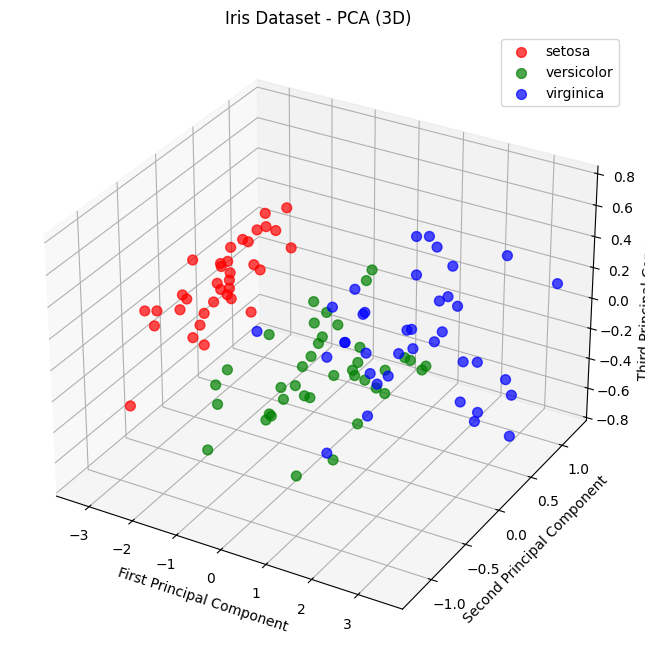

In [10]:
# Plot the 3D dataset after PCA
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot each class with a different color
colors = ['red', 'green', 'blue']
for i, color in enumerate(colors):
    mask = y_train == i
    ax.scatter(X3D[mask, 0], X3D[mask, 1], X3D[mask, 2],
               c=color, label=iris_dataset.target_names[i], s=50, alpha=0.7)

ax.set_xlabel('First Principal Component')
ax.set_ylabel('Second Principal Component')
ax.set_zlabel('Third Principal Component')
ax.set_title('Iris Dataset - PCA (3D)')
ax.legend()
plt.show()

In [11]:
tsne = TSNE(n_components=3, random_state=42)
X_reduced_tsne = tsne.fit_transform(X_train)

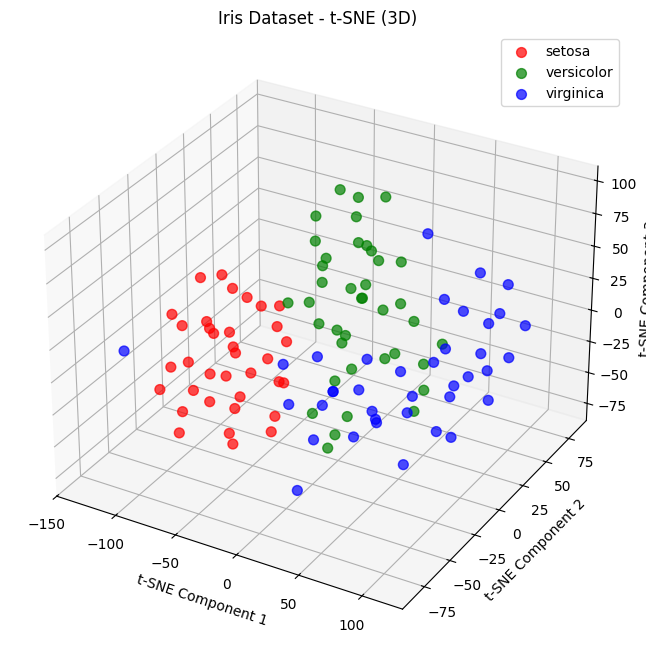

In [13]:
# Plot the 3D dataset after t-SNE
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot each class with a different color
for i, color in enumerate(colors):
    mask = y_train == i
    ax.scatter(X_reduced_tsne[mask, 0], X_reduced_tsne[mask, 1], X_reduced_tsne[mask, 2],
               c=color, label=iris_dataset.target_names[i], s=50, alpha=0.7)

ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_zlabel('t-SNE Component 3')
ax.set_title('Iris Dataset - t-SNE (3D)')
ax.legend()
plt.show()

## 2. Digits Dataset Classification with SVM

Use the digits dataset to perform a classification task using Linear Support Vector Machine (SVM). Set the parameter C to 5. Split the data such that the test split is 25% of the initial dataset. Compare the image classification task using the original number of features (64) to the reduced features (20) using the PCA algorithm. Compare:

- the training time for both models;
- the difference in accuracy score.

In [17]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from time import time
from sklearn.decomposition import PCA

In [4]:
digits_dataset = load_digits()

X = digits_dataset['data']
y = digits_dataset['target']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.25,
                                                    random_state = 42)

In [9]:
svm_clf = SVC(kernel="linear", C = 5)

In [15]:
t0 = time()

svm_clf.fit(X_train, y_train)

t1 = time() - t0

print("Training time with original features(64) : ", t1)

Training time with original features(64) :  0.0491032600402832


In [16]:
accuracy_original = svm_clf.score(X_test, y_test)
print("Accuracy with original features(64) : ", accuracy_original)

Accuracy with original features(64) :  0.9822222222222222


In [18]:
pca = PCA(n_components = 20)

X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)

In [19]:
svm_clf = SVC(kernel="linear", C = 5)

In [20]:
t0 = time()

svm_clf.fit(X_train_reduced, y_train)

t1 = time() - t0

print("Training time with original features(64) : ", t1)

Training time with original features(64) :  0.05126309394836426


In [21]:
accuracy_reduced = svm_clf.score(X_test_reduced, y_test)
print("Accuracy with reduced features(20):", accuracy_reduced)

Accuracy with reduced features(20): 0.9733333333333334
